## Forecasting Marikina River Level using Bidirectional Transformer

### Import Dataset and Libraries

In [1]:
import time
import calendar
from datetime import datetime
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from skimage.measure import block_reduce
from sklearn.metrics import mean_absolute_error

import copy
import math
import torch
import torch.nn as nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # configure GPU utilization
device

device(type='cuda', index=0)

In [2]:
df = pd.read_csv('riverlevel.csv')  # import dataset

# convert month name to integer
month_dict = dict((v, k) for k, v in enumerate(calendar.month_name))
df['Month'] = df['Month'].map(month_dict)

# create datetime column
df[['Year', 'Month', 'Day', 'Hour']] = df[['Year', 'Month', 'Day', 'Hour']].astype(int)
df['Hour'] = df['Hour'].apply(lambda x: x if x < 24 else 0)

# convert year, month, day, and hour columns into timestamp
df['Datetime'] = df[['Year', 'Month', 'Day', 'Hour']].apply(lambda row: datetime(row['Year'], row['Month'], row['Day'], row['Hour']).isoformat(), axis=1)
df["Datetime"] = pd.to_datetime(df["Datetime"], format='ISO8601')

# assign timestamps as the data frame index
df.index = df["Datetime"]
df = df.drop(['Datetime'], axis=1)

# select the parameters
df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'Waterlevel.3', 'RF-Intensity', 'RF-Intensity.2', 'RF-Intensity.3', 'Precipitation', 'Precipitation.1', 'Precipitation.2', 'Humidity', 'Humidity.1', 'Humidity.2', 'Temperature', 'Temperature.1', 'Temperature.2']] 
df = df.astype(np.float64)  # convert parameters into a double precision floating number

# fill in missing values using linear interpolation
df = df.interpolate(method='linear', limit_direction='forward')
df = df.resample('6H').max()  # resample dataset using the max value for each 24-hours
df = df.rolling(120).mean().dropna()  # perform moving average smoothing

df.head(10)  # display data frame

,Waterlevel,Waterlevel.1,Waterlevel.2,Waterlevel.3,RF-Intensity,RF-Intensity.2,RF-Intensity.3,Precipitation,Precipitation.1,Precipitation.2,Humidity,Humidity.1,Humidity.2,Temperature,Temperature.1,Temperature.2
Datetime,,,,,,,,,,,,,,,,
2012-01-30 18:00:00,15.846000,12.326500,12.326500,21.908917,0.408333,0.241667,0.241667,0.387917,0.387917,0.387917,17.221333,17.221333,17.221333,25.270667,25.270667,25.270667
2012-01-31 00:00:00,15.845667,12.322500,12.322500,21.907500,0.408333,0.241667,0.241667,0.391917,0.391917,0.391917,17.214667,17.214667,17.214667,25.255583,25.255583,25.255583
2012-01-31 06:00:00,15.845250,12.318500,12.318500,21.905917,0.408333,0.241667,0.241667,0.399583,0.399583,0.399583,17.214083,17.214083,17.214083,25.258750,25.258750,25.258750
2012-01-31 12:00:00,15.844833,12.314500,12.314500,21.904408,0.408333,0.250000,0.250000,0.406500,0.406500,0.406500,17.217167,17.217167,17.217167,25.261667,25.261667,25.261667
2012-01-31 18:00:00,15.843833,12.310500,12.310500,21.902883,0.408333,0.250000,0.250000,0.409917,0.409917,0.409917,17.219667,17.219667,17.219667,25.263500,25.263500,25.263500
2012-02-01 00:00:00,15.843500,12.306500,12.306500,21.901339,0.408333,0.250000,0.250000,0.418417,0.418417,0.418417,17.221667,17.221667,17.221667,25.266083,25.266083,25.266083
2012-02-01 06:00:00,15.843167,12.302500,12.302500,21.899864,0.408333,0.250000,0.250000,0.427417,0.427417,0.427417,17.218167,17.218167,17.218167,25.244167,25.244167,25.244167
2012-02-01 12:00:00,15.842750,12.298500,12.298500,21.898372,0.408333,0.216667,0.216667,0.435417,0.435417,0.435417,17.214083,17.214083,17.214083,25.223667,25.223667,25.223667
2012-02-01 18:00:00,15.842417,12.294500,12.294500,21.896947,0.408333,0.216667,0.216667,0.435250,0.435250,0.435250,17.210000,17.210000,17.210000,25.220083,25.220083,25.220083


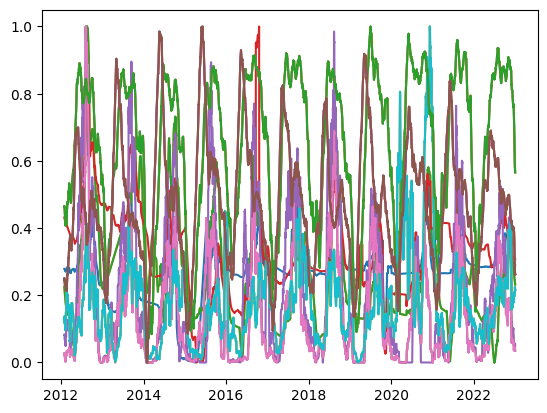

In [3]:
# scale data
scaler = MinMaxScaler()
scaler.fit(df)

# train label scaler
label_scaler = MinMaxScaler()
label_scaler.fit(df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'Waterlevel.3']])

scaled_ds = scaler.transform(df)
df = pd.DataFrame(scaled_ds, columns=df.columns, index=df.index)

# visualize dataset
plt.plot(df)
plt.show()

### Build Model

In [4]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_len, step):
        self.data = data
        self.seq_len = seq_len
        self.step = step
        
    def __getitem__(self, index):
        in_start = index
        in_end = in_start + self.seq_len
        out_start = index + self.step
        out_end = out_start + self.seq_len
        
        inputs = self.data[in_start:in_end]
        labels = self.data[out_start:out_end, :4]
        
        return inputs, labels
    
    def __len__(self):
        return len(self.data) - (self.seq_len + self.step) + 1

In [5]:
BATCH_SIZE = 128
SEQ_LEN = 60
SEQ_STEP = 60
PRED_SIZE = 4
D_MODEL = 16
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 2048 
DROPOUT = 0.10

#### Attention Mechanism

In the context of forecasting, a multi-head attention mechanism allows the model to weigh the importance of different time points in a time period thus allowing the model to capture the relationship between past events and current events. The attention scores are calculated by comparing the input sequence (after linear projection) against itself or against a query vector. In addition, the diagonal mask ensure that the attention mechanism only compares past events to future events but not vice versa to avoid over fitting.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        
        return attn_probs, output
        
    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        attn_scores, attn_output = self.scaled_dot_product_attention(Q, K, V)
        output = self.W_o(self.combine_heads(attn_output))
        return attn_scores, output

#### Positional Encoding

Unlike human brains, neural networks are not aware of order. It cannot distinguish past values from future values. That is why, the purpose of positional encoding is to help the model distinguish between different elements in a sequence and understand the sequential order of data.

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=2048):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#### Feed Forward Network

Feed Forward Network is a fundamental type of artificial neural network. In the context of transformer models, the feed forward network aims to learn the relationship between the temporal features and the forecasted values.

In [8]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

#### Decoder Layer

The decoder layer is the combination of masked attention mechanisms and a feed forward network. The primary purpose of the decoder layer is to generate future values in a autoregressive manner, based on the context and extracted features from seasonal trend decomposition and attention mechanism.

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        attn_scores, attn_output = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return attn_scores, x

In [10]:
class Transformer(nn.Module):
    def __init__(self, pred_size, d_model, num_heads, num_layers, d_ff, dropout):
        super(Transformer, self).__init__()
        self.positional_encoding = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, pred_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt):
        tgt_embedded = self.dropout(self.positional_encoding(tgt))

        enc_output = tgt_embedded
        for enc_layer in self.encoder_layers:
            attn_scores, enc_output = enc_layer(enc_output)

        output = self.sigmoid(self.fc(enc_output))
        return attn_scores, output

In [11]:
# define the model
decomposer = Transformer(
    pred_size=PRED_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).float()

decomposer.to(device)

device

device(type='cuda', index=0)

In [12]:
# test if the model is working properly using random values
decomposer.eval()

sample = np.random.rand(1, SEQ_LEN, D_MODEL)
output = torch.from_numpy(sample).float().to(device)
scores, output = decomposer(output)
output = output.detach().cpu().numpy()
scores = scores.detach().cpu().numpy()

print(output.shape)
print(scores.shape)

(1, 60, 4)
(1, 4, 60, 60)


### Train Model

In [13]:
def train_decomposer(train_dataloader, val_dataloader, epochs=10, es_value=0.010):
    time_now = time.time()
    train_steps = len(train_dataloader)
    train_epochs = epochs

    # initialize optimizer that will adjust the model's weights and biases during training
    model_optim = torch.optim.Adam(decomposer.parameters(), lr=0.001)
    
    # initialize loss function that will determine the error between the actual values and forecasted values
    loss_fn = torch.nn.MSELoss()

    for epoch in range(train_epochs):
        iter_count = 0
        train_loss = []

        decomposer.train()
        epoch_time = time.time()
        for i, (inputs, labels) in enumerate(train_dataloader):
            iter_count += 1
            model_optim.zero_grad()  # reset gradients
            
            batch_x = inputs.float().to(device)  # convert values to float and send to GPU
            batch_y = labels.float().to(device)  # convert values to float and send to GPU

            scores, outputs = decomposer(batch_x) 

            loss = loss_fn(outputs, batch_y)
            train_loss.append(loss.item())

            loss.backward()  # compute gradients
            model_optim.step()  # update model parameters
            
            if (i + 1) % 20 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time() 

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        
        # evaluate model
        val_loss = []
        decomposer.eval()
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(val_dataloader):
                batch_x = inputs.float().to(device)
                batch_y = labels.float()

                scores, outputs = decomposer(batch_x)
                outputs = outputs.detach().cpu()

                loss = loss_fn(outputs, batch_y)

                val_loss.append(loss)
        val_loss = np.average(val_loss)
        
        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Validation Loss: {3:.7f}".format(epoch + 1, train_steps, train_loss, val_loss))
        
        # stop training upon reaching the optimal accuracy to avoid over fitting
        if val_loss < es_value:
            break
        
        decomposer.train()
        
    torch.save(decomposer.state_dict(), 'transformer.pth')  # save model

In [14]:
train_data = df['2012-01-01':'2020-01-01'].values
val_data = df['2020-01-01':'2021-01-01'].values

train_dataset = TimeSeriesDataset(train_data, seq_len=SEQ_LEN, step=SEQ_STEP)
val_dataset = TimeSeriesDataset(val_data, seq_len=SEQ_LEN, step=SEQ_STEP)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print('Train Batches:', len(train_dataloader))
print('Val Batches:', len(val_dataloader))

Train Batches: 90
Val Batches: 11


In [123]:
train_decomposer(train_dataloader, val_dataloader, epochs=20, es_value=0.009)

	iters: 20, epoch: 1 | loss: 0.0139840
	speed: 0.0346s/iter; left time: 61.7115s
	iters: 40, epoch: 1 | loss: 0.0109855
	speed: 0.0332s/iter; left time: 58.5532s
	iters: 60, epoch: 1 | loss: 0.0193138
	speed: 0.0332s/iter; left time: 57.8012s
	iters: 80, epoch: 1 | loss: 0.0078072
	speed: 0.0506s/iter; left time: 86.9970s
Epoch: 1 cost time: 3.369997262954712
Epoch: 1, Steps: 90 | Train Loss: 0.0280705 Validation Loss: 0.0103852
	iters: 20, epoch: 2 | loss: 0.0268089
	speed: 0.0796s/iter; left time: 134.6876s
	iters: 40, epoch: 2 | loss: 0.0170121
	speed: 0.0329s/iter; left time: 54.8924s
	iters: 60, epoch: 2 | loss: 0.0214558
	speed: 0.0329s/iter; left time: 54.2354s
	iters: 80, epoch: 2 | loss: 0.0089295
	speed: 0.0330s/iter; left time: 53.7415s
Epoch: 2 cost time: 2.958008050918579
Epoch: 2, Steps: 90 | Train Loss: 0.0287364 Validation Loss: 0.0108262
	iters: 20, epoch: 3 | loss: 0.0290785
	speed: 0.0758s/iter; left time: 121.2780s
	iters: 40, epoch: 3 | loss: 0.0161042
	speed: 0.03

### Test Model

In [15]:
test_data = df['2021-01-01':'2023-01-01'].values

test_dataset = TimeSeriesDataset(test_data, seq_len=SEQ_LEN, step=SEQ_STEP)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=len(test_data),
    shuffle=False,
    drop_last=False
)

print(test_data.shape)

(2920, 16)


In [16]:
decomposer.load_state_dict(torch.load('transformer.pth'))  # load the trained model

decomposer.eval()  # set model on test mode

inputs, labels = [(inputs, labels) for _, (inputs, labels) in enumerate(test_dataloader)][0]  # fetch the test dataset

print(inputs.shape)
print(labels.shape)

torch.Size([2801, 60, 16])
torch.Size([2801, 60, 4])


In [17]:
# measure accuracy of each window
accuracy = []
predictions = []
for i in range(len(inputs)):
    x_test = inputs[i:(i+1)].float().to(device)

    attn_scores, y_test = decomposer(x_test)  # make forecast
    y_test = torch.squeeze(y_test, dim=0)
    y_test = y_test.detach().cpu().numpy()  # transfer output from GPU to CPU
    y_test = label_scaler.inverse_transform(y_test[:, :4])  # scale output to original value

    # evaluate model accuracy
    ground = torch.squeeze(labels[i:(i+1)], dim=0)  # get observed values
    ground = ground.numpy()
    ground = label_scaler.inverse_transform(ground[:, :4])  # scale output to original value

    accuracy.append(mean_absolute_error(ground, y_test))  # collect mean absolute error of each window
    predictions.append(np.concatenate((y_test[0], ground[0])))  # collect first element of output
    
accuracy_df = pd.DataFrame(np.array(accuracy), columns=['MAE'])
predictions_df = pd.DataFrame(np.array(predictions), columns=['P_Waterlevel', 'P_Waterlevel.1', 'P_Waterlevel.2', 'P_Waterlevel.3', 'T_Waterlevel', 'T_Waterlevel.1', 'T_Waterlevel.2', 'T_Waterlevel.3'])
metric_df = pd.concat([accuracy_df, predictions_df], axis=1)
metric_df.index = df.index[-len(metric_df):]

metric_df = metric_df.resample('24H').max()

metric_df.to_csv('results.csv')  # save test results

metric_df.head(10)

,MAE,P_Waterlevel,P_Waterlevel.1,P_Waterlevel.2,P_Waterlevel.3,T_Waterlevel,T_Waterlevel.1,T_Waterlevel.2,T_Waterlevel.3
Datetime,,,,,,,,,
2021-01-30,0.529884,15.794814,12.230573,12.236510,21.051470,15.817826,12.746213,12.746213,21.756250
2021-01-31,0.536945,15.794403,12.233181,12.238483,21.054035,15.817510,12.743925,12.743925,21.756250
2021-02-01,0.544511,15.793590,12.235559,12.240335,21.056456,15.816300,12.734825,12.734825,21.756250
2021-02-02,0.552278,15.794272,12.236668,12.241321,21.057674,15.815176,12.724607,12.724607,21.756000
2021-02-03,0.558664,15.794475,12.238472,12.242708,21.059460,15.837998,12.734888,12.734888,21.786667
2021-02-04,0.559809,15.797412,12.242709,12.246960,21.064600,15.886859,12.766407,12.766407,21.838667
2021-02-05,0.557547,15.799338,12.249731,12.253710,21.072592,15.962389,12.806653,12.806653,21.874000
2021-02-06,0.550221,15.799731,12.258670,12.261727,21.082157,16.038004,12.806049,12.806049,21.878417
2021-02-07,0.541457,15.800872,12.266823,12.269607,21.091232,16.113704,12.803488,12.803488,21.882083


In [18]:
print('Average Mean Absolute Error:', metric_df['MAE'].mean())
print('Mean Absolute Error STD:', metric_df['MAE'].std())

Average Mean Absolute Error: 0.273514153259132
Mean Absolute Error STD: 0.097103258169034


In [19]:
print('Mean Absolute Error:', mean_absolute_error(metric_df[['T_Waterlevel', 'T_Waterlevel.1', 'T_Waterlevel.2', 'T_Waterlevel.3']], metric_df[['P_Waterlevel', 'P_Waterlevel.1', 'P_Waterlevel.2', 'P_Waterlevel.3']]))

Mean Absolute Error: 0.2589190888465758


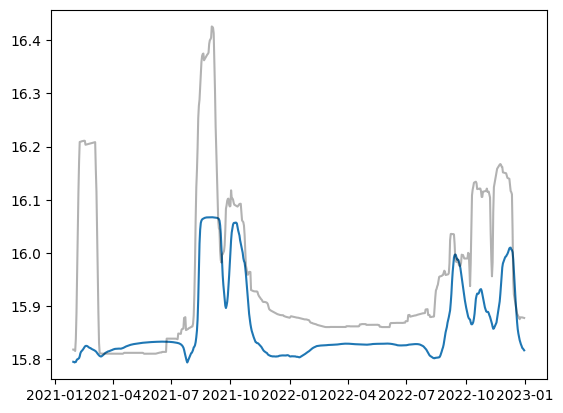

In [20]:
plt.plot(metric_df['P_Waterlevel'])  # plot predictions
plt.plot(metric_df['T_Waterlevel'], color='k', alpha=0.3)  # plot observed value
plt.show()

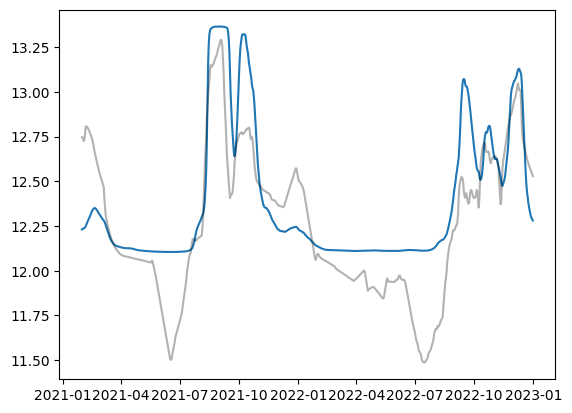

In [21]:
plt.plot(metric_df['P_Waterlevel.1'])  # plot predictions
plt.plot(metric_df['T_Waterlevel.1'], color='k', alpha=0.3)  # plot observed value
plt.show()

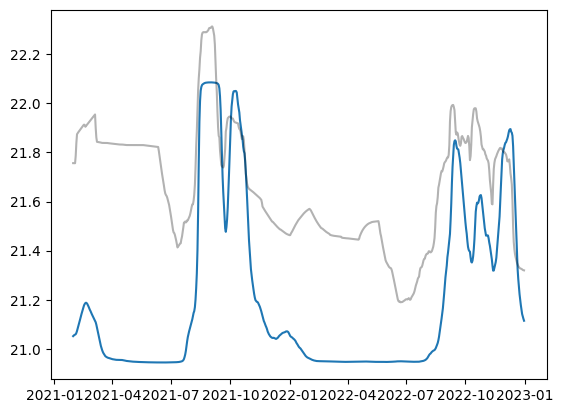

In [22]:
plt.plot(metric_df['P_Waterlevel.3'])  # plot predictions
plt.plot(metric_df['T_Waterlevel.3'], color='k', alpha=0.3)  # plot observed value
plt.show()

In [23]:
def plot_forecast(window, kernel_size=9):
    x_test = inputs[window:(window+1)].float().to(device)
    indexes = df.index[-1460:]

    attn_scores, y_test = decomposer(x_test)  # make forecast
    y_test = torch.squeeze(y_test, dim=0)
    y_test = y_test.detach().cpu().numpy()  # transfer output from GPU to CPU
    y_test = label_scaler.inverse_transform(y_test[:, :4])  # scale output to original value
    y_test = y_test[-(SEQ_STEP * 2):]  # get only the forecast window

    ground = torch.squeeze(labels[window:(window+1)], dim=0)  # get observed values
    ground = ground.numpy()
    ground = label_scaler.inverse_transform(ground[:, :4])  # scale output to original value
    ground = ground[-(SEQ_STEP * 2):]  # get only the forecast window
    
    # plot predictions
    for i in [0, 1, 3]:
        plt.plot(y_test[:, i])
        plt.plot(ground[:, i], color='k', alpha=0.3)
        plt.show()
    
    # plot attention scores
    attn_scores = torch.squeeze(attn_scores, dim=0)
    attn_scores = attn_scores.detach().cpu().numpy()  # transfer output from GPU to CPU
    for attention in attn_scores:
        ax = plt.gca()
        attention = attention[10:]
        attention = block_reduce(attention, (kernel_size, kernel_size), np.max)
        ax.matshow(attention)
        plt.show()

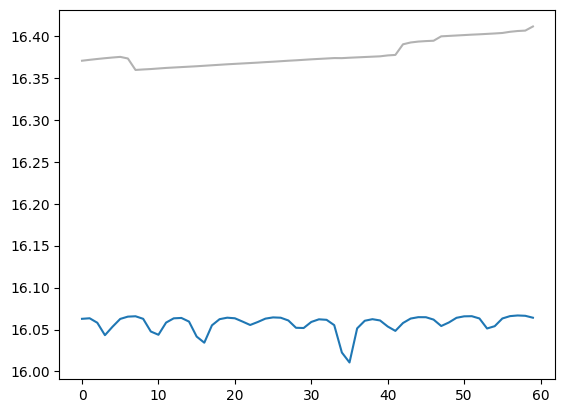

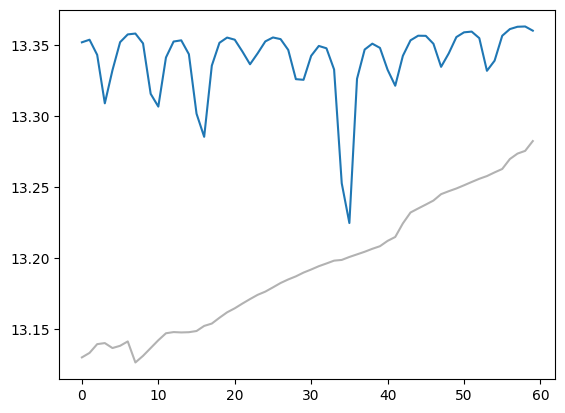

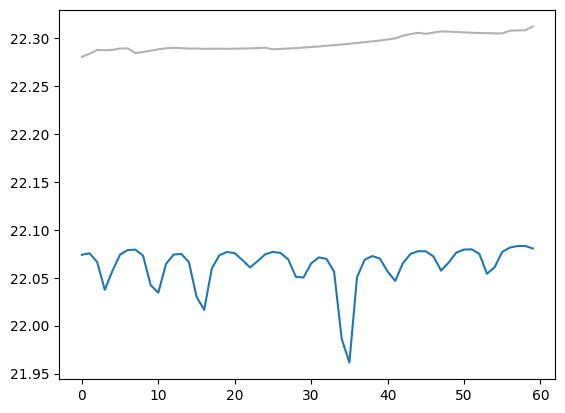

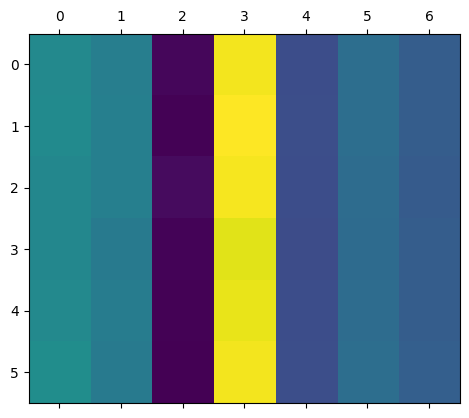

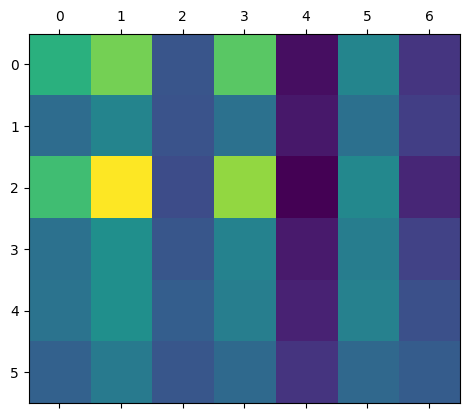

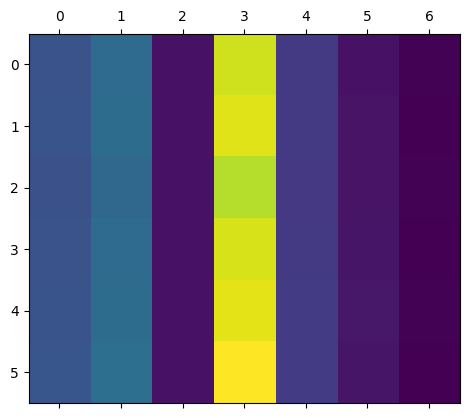

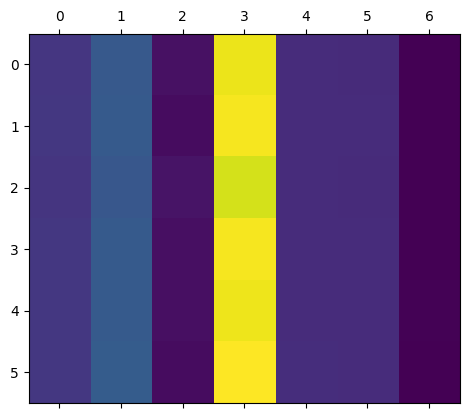

In [24]:
plot_forecast(window=800)

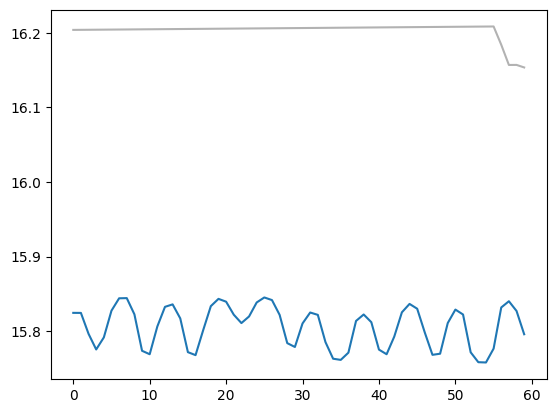

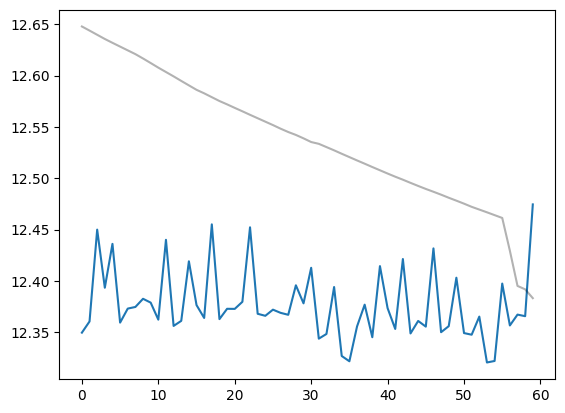

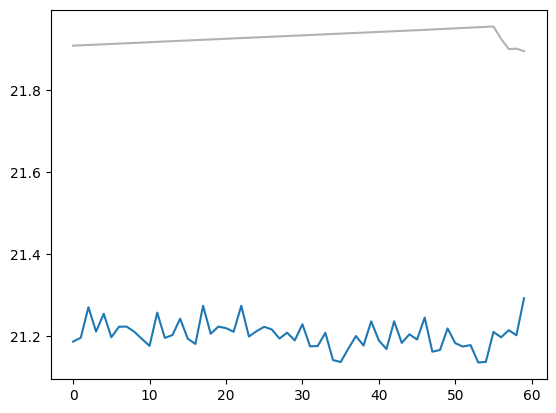

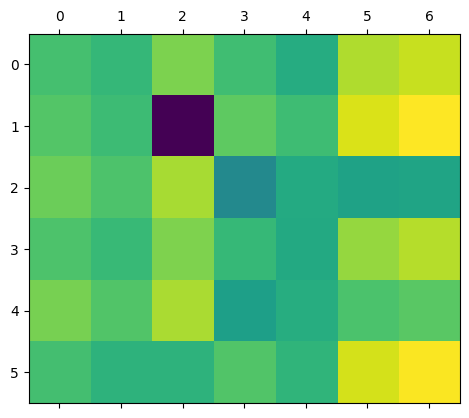

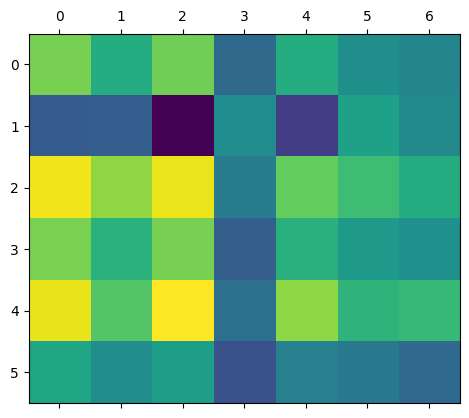

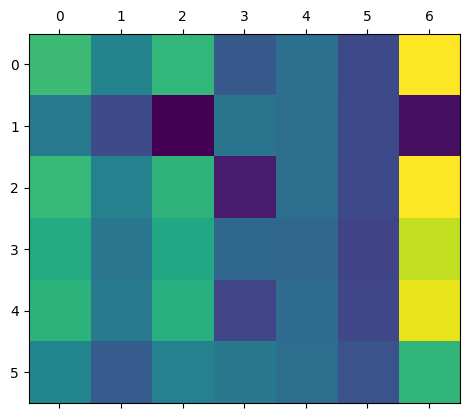

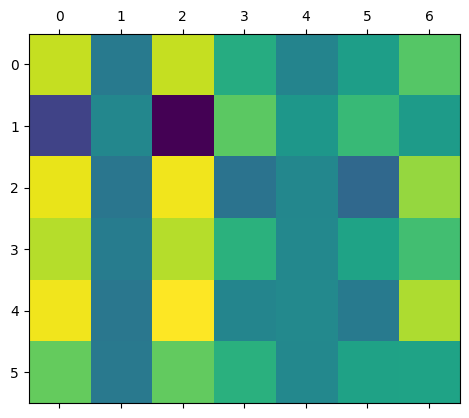

In [25]:
plot_forecast(window=80)

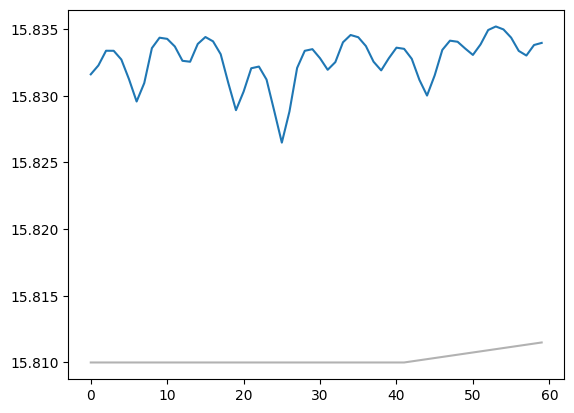

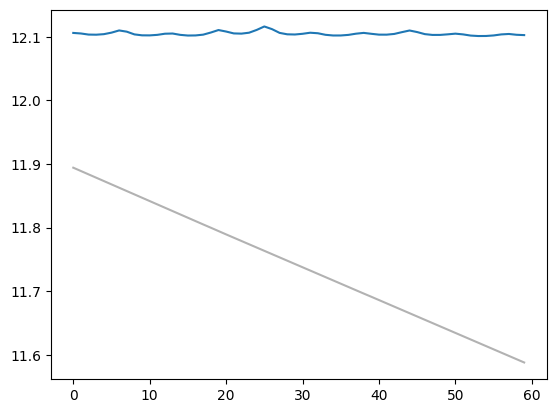

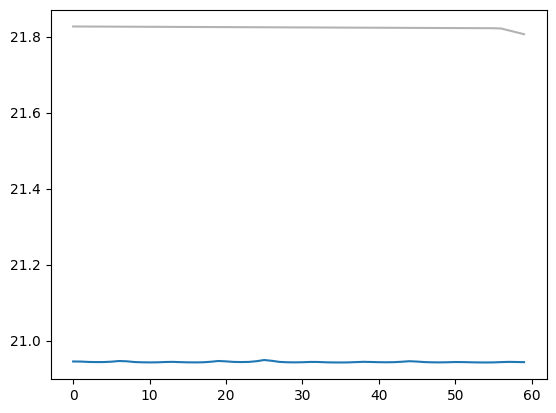

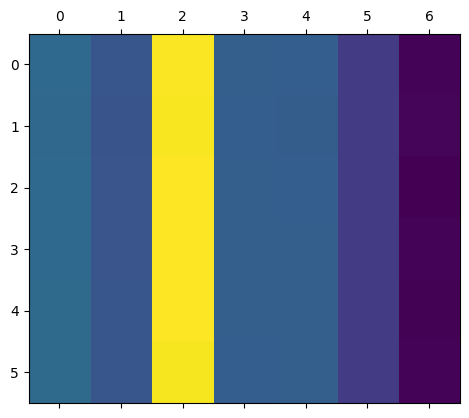

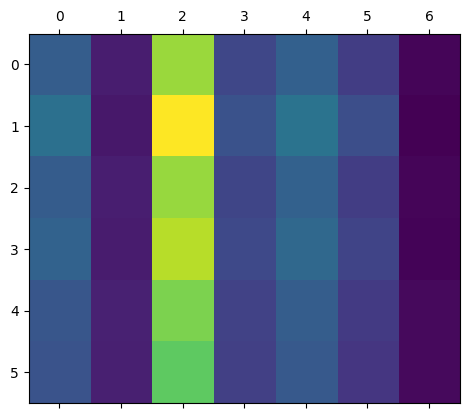

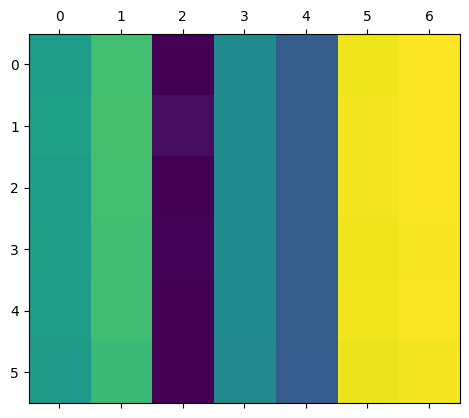

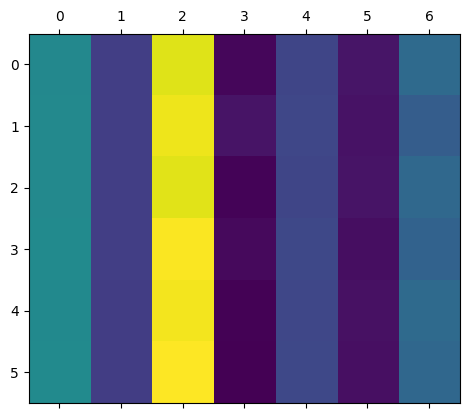

In [26]:
plot_forecast(window=470)